In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob

In [4]:
df = pd.read_csv('social_media_data.csv')
df.head(10)

,text,user,location,date,likes,comments,shares,brand
0,Nike shoes are amazing! #Nike #Running,user1,Mumbai,2024-01-01,120,30,15,Nike
1,Adidas new collection is great #Adidas,user2,Delhi,2024-01-02,85,20,10,Adidas
2,I love my Nike trainers best ever!,user3,Mumbai,2024-01-03,200,50,25,Nike
3,Adidas vs Nike which is better?,user4,Pune,2024-01-04,60,10,5,Adidas
4,Nike Air Max release today #Nike #Shoes,user5,Delhi,2024-01-05,175,45,20,Nike
5,Worst experience with Adidas support,user6,Mumbai,2024-01-06,30,5,2,Adidas
6,Running with Nike feels incredible,user7,Chennai,2024-01-07,140,35,18,Nike
7,Adidas ultraboost very comfortable shoes,user8,Pune,2024-01-08,90,25,12,Adidas
8,Nike just released new gear #Nike,user9,Delhi,2024-01-09,160,40,22,Nike
9,Adidas collaboration is fire #Fashion,user10,Mumbai,2024-01-10,110,28,14,Adidas


In [6]:
df['engagement'] = df['likes'] + df['shares'] + df['comments']
print(df.head())

                                      text   user location        date  likes  \
0   Nike shoes are amazing! #Nike #Running  user1   Mumbai  2024-01-01    120   
1   Adidas new collection is great #Adidas  user2    Delhi  2024-01-02     85   
2       I love my Nike trainers best ever!  user3   Mumbai  2024-01-03    200   
3          Adidas vs Nike which is better?  user4     Pune  2024-01-04     60   
4  Nike Air Max release today #Nike #Shoes  user5    Delhi  2024-01-05    175   

   comments  shares   brand  engagement  
0        30      15    Nike         165  
1        20      10  Adidas         115  
2        50      25    Nike         275  
3        10       5  Adidas          75  
4        45      20    Nike         240  


In [8]:
polarity = []
for text in df['text']:
    p = TextBlob(text).sentiment.polarity
    polarity.append(p)
df['polarity'] = polarity

print(df.head())

                                      text   user location        date  likes  \
0   Nike shoes are amazing! #Nike #Running  user1   Mumbai  2024-01-01    120   
1   Adidas new collection is great #Adidas  user2    Delhi  2024-01-02     85   
2       I love my Nike trainers best ever!  user3   Mumbai  2024-01-03    200   
3          Adidas vs Nike which is better?  user4     Pune  2024-01-04     60   
4  Nike Air Max release today #Nike #Shoes  user5    Delhi  2024-01-05    175   

   comments  shares   brand  engagement  polarity  
0        30      15    Nike         165  0.750000  
1        20      10  Adidas         115  0.468182  
2        50      25    Nike         275  0.750000  
3        10       5  Adidas          75  0.500000  
4        45      20    Nike         240  0.000000  


In [11]:
nike_df = df[df['brand'].str.contains(
    r'\bnike\b',case=False,na=False )]
adidas_df = df[df['brand'].str.contains(
    r'\badidas\b',case=False,na=False )]

In [14]:
print(nike_df)
print(adidas_df)

                                      text   user location        date  likes  \
0   Nike shoes are amazing! #Nike #Running  user1   Mumbai  2024-01-01    120   
2       I love my Nike trainers best ever!  user3   Mumbai  2024-01-03    200   
4  Nike Air Max release today #Nike #Shoes  user5    Delhi  2024-01-05    175   
6       Running with Nike feels incredible  user7  Chennai  2024-01-07    140   
8        Nike just released new gear #Nike  user9    Delhi  2024-01-09    160   

   comments  shares brand  engagement  polarity  
0        30      15  Nike         165  0.750000  
2        50      25  Nike         275  0.750000  
4        45      20  Nike         240  0.000000  
6        35      18  Nike         193  0.900000  
8        40      22  Nike         222  0.136364  
                                       text    user location        date  \
1    Adidas new collection is great #Adidas   user2    Delhi  2024-01-02   
3           Adidas vs Nike which is better?   user4     Pune 

In [19]:
#Post
nike_posts = len(nike_df)
adidas_posts = len(adidas_df)

In [20]:
#Engagement
nike_eng = nike_df['engagement'].mean()
adidas_eng = adidas_df['engagement'].mean()

In [21]:
#Sentiment
nike_senti = nike_df['polarity'].mean()
adidas_senti = adidas_df['polarity'].mean()

In [24]:
print("Nike:" ,nike_posts, nike_eng, nike_senti)
print("Adidas:" ,adidas_posts, adidas_eng, adidas_senti)

Nike: 5 219.0 0.5072727272727272
Adidas: 5 101.2 0.09763636363636366


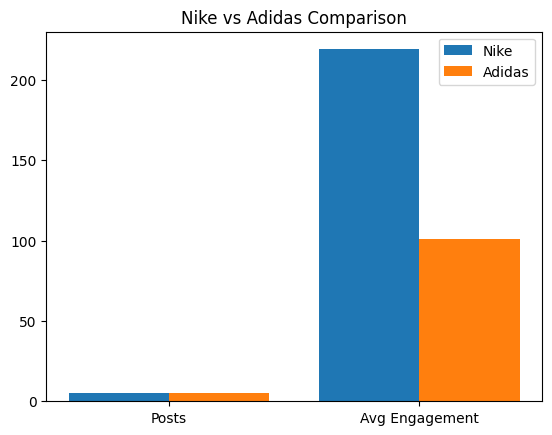

In [40]:
labels = ['Posts', 'Avg Engagement']

x = [0,1]
nike_vals=[nike_post,nike_eng]
plt.bar(x,nike_vals,width=0.4,label='Nike')

x2=[0.4,1.4]
adidas_vals = [adidas_post, adidas_eng]
plt.bar(x2,adidas_vals, width=0.4, label='Adidas')

plt.xticks([0.2,1.2],labels)
plt.title('Nike vs Adidas Comparison')
plt.legend()
plt.show()
